In [2]:
# various import statements
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import pyro

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import sys
import antipode
from antipode.antipode_model import *
import antipode.model_functions
from antipode.model_functions import *
import antipode.model_distributions
from antipode.model_distributions import *
import antipode.model_modules
from antipode.model_modules import *
import antipode.train_utils
from antipode.train_utils import *
import antipode.plotting
from antipode.plotting import *

GPU is not available


In [3]:
adata=sc.read_h5ad(os.path.expanduser('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/integration_test/Immune_ALL_hum_mou.h5ad'),backed=True)
adata.uns['species_colors']=['blue','red','green','yellow','orange','cyan','magenta','teal','goldenrod','purple','maroon','pink','violet','black','grey','beige']
batch_key='batch'
discov_key='species'
layer_key='counts'

In [4]:
adata

AnnData object with n_obs × n_vars = 97861 × 8135 backed at '/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/integration_test/Immune_ALL_hum_mou.h5ad'
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'size_factors', 'species', 'study', 'tissue'
    uns: 'species_colors'
    layers: 'counts'

In [5]:
adata.obs['countsum']=adata.layers['counts'].sum(-1)

100%|██████████| 6/6 [00:12<00:00,  2.03s/it]


<Axes: ylabel='Proportion'>

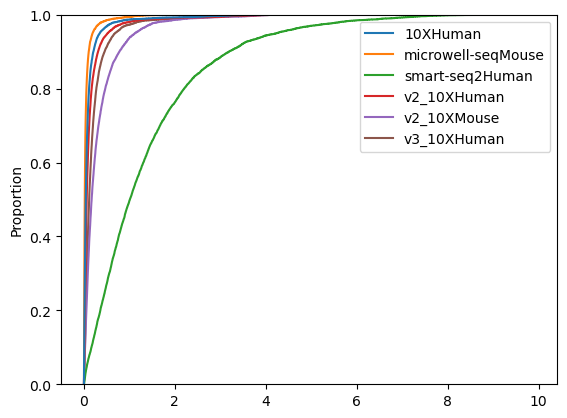

In [6]:
adata.obs['species_chemistry']=adata.obs['chemistry'].astype(str)+adata.obs['species'].astype(str)
adata.obs['species_chemistry']=adata.obs['species_chemistry'].astype('category')
outs=antipode.model_functions.group_aggr_anndata(adata,['species_chemistry'])
seaborn.ecdfplot(pd.DataFrame(outs[0],index=outs[1]['species_chemistry']).T)

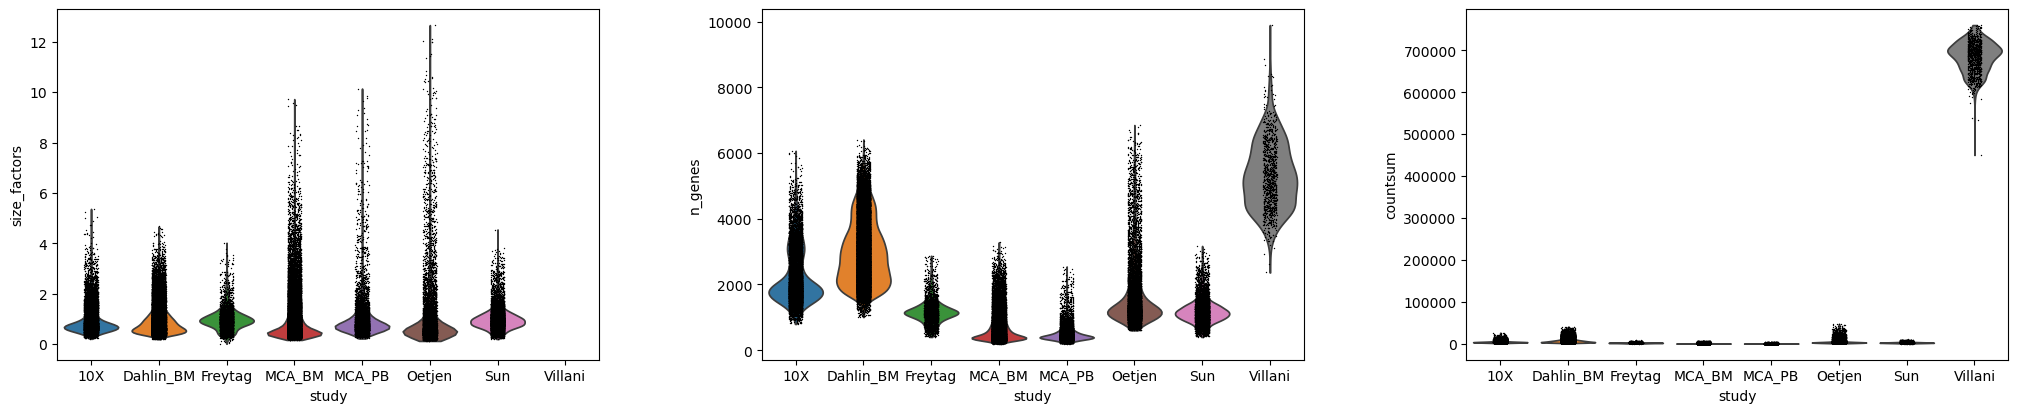

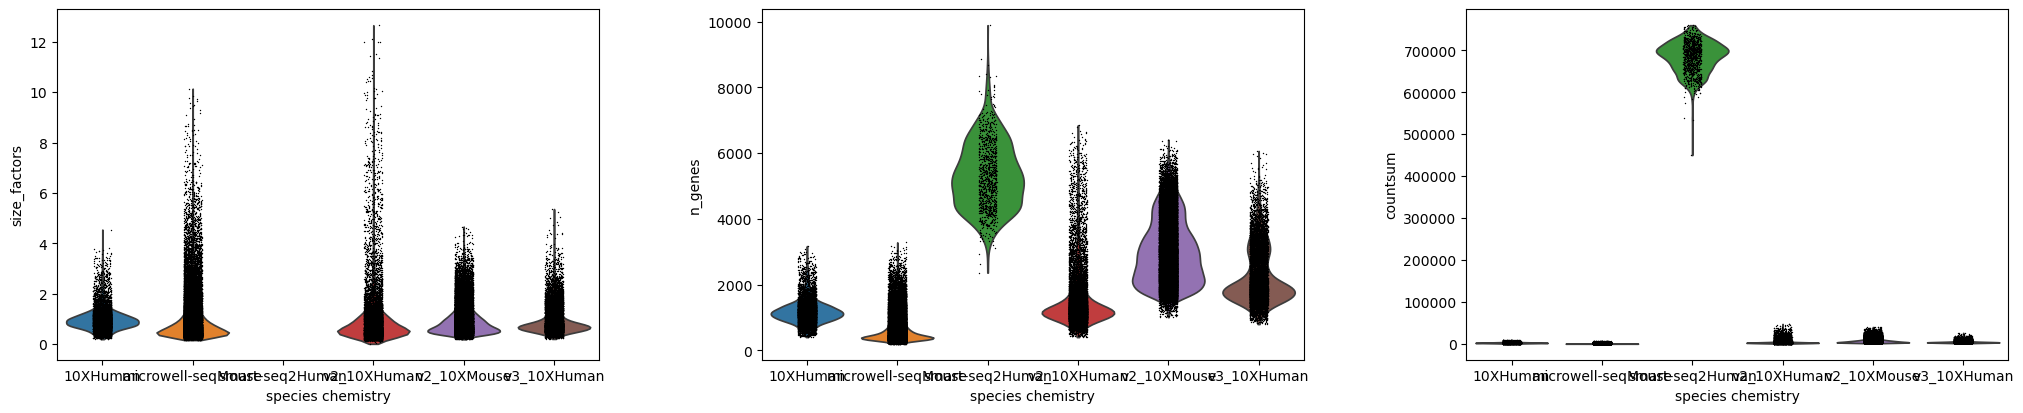

In [7]:
sc.pl.violin(adata,groupby='study',keys=['size_factors','n_genes','countsum'])
sc.pl.violin(adata,groupby='species_chemistry',keys=['size_factors','n_genes','countsum'])


In [8]:
adata=sc.read_h5ad(os.path.expanduser('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/deliveries/bg/BG_M-Q.h5ad'),backed='r')
adata.uns['species_colors']=['blue','orange']
batch_key='load_name'
discov_key='species'
layer_key='UMIs'

In [9]:
adata

AnnData object with n_obs × n_vars = 757572 × 16046 backed at '/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/deliveries/bg/BG_M-Q.h5ad'
    obs: 'sample_id', 'bc', 'ar_id', 'umi.counts', 'barcodes', 'gene.counts.0', 'gene.counts.1', 'gene.counts.4', 'gene.counts.8', 'gene.counts.16', 'gene.counts.32', 'gene.counts.64', 'exclude', 'X', 'exp_component_name', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'reference_id', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'expc_cell_capture', 'sample_quantity_pg', 'donor_name', 'external_donor_name', 'age', 'species', 'sex', 'control', 'cell_prep_type', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'injection_roi', 'injec

In [15]:
adata.obs['countsum']=adata.layers['UMIs'].sum(-1)
adata.obs['logcountsum']=np.log10(adata.layers['UMIs'].sum(-1))

100%|██████████| 2/2 [06:16<00:00, 188.24s/it]


<Axes: ylabel='Proportion'>

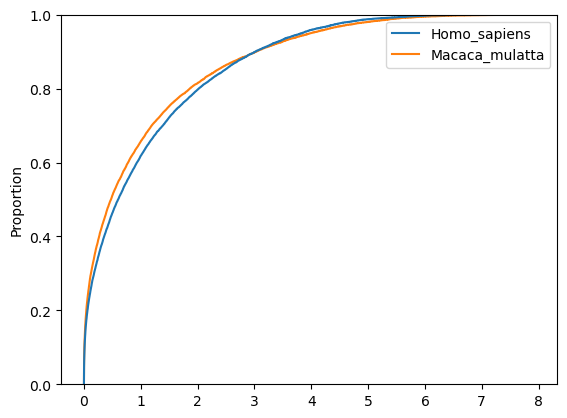

In [11]:
outs=antipode.model_functions.group_aggr_anndata(adata,['species'])
seaborn.ecdfplot(pd.DataFrame(outs[0],index=outs[1]['species']).T)

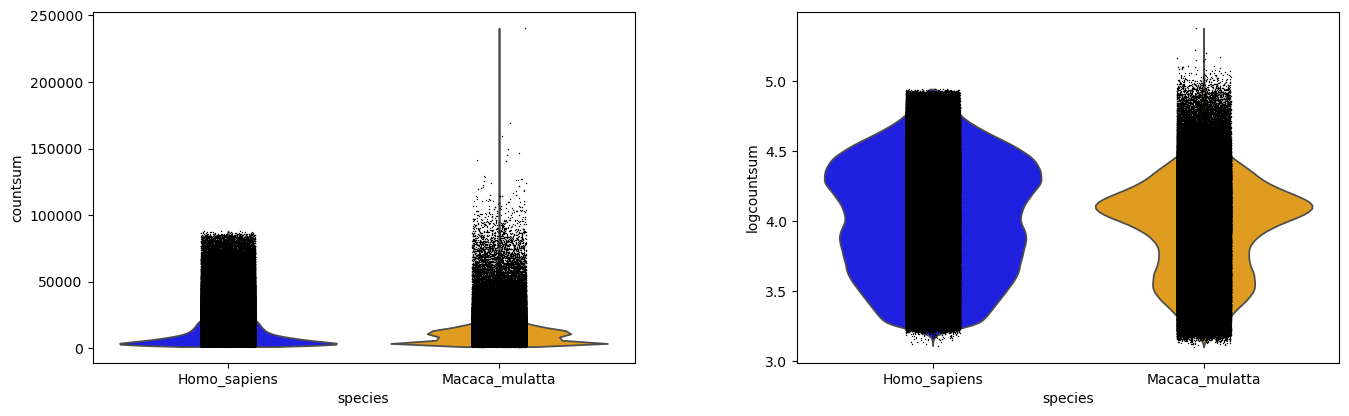

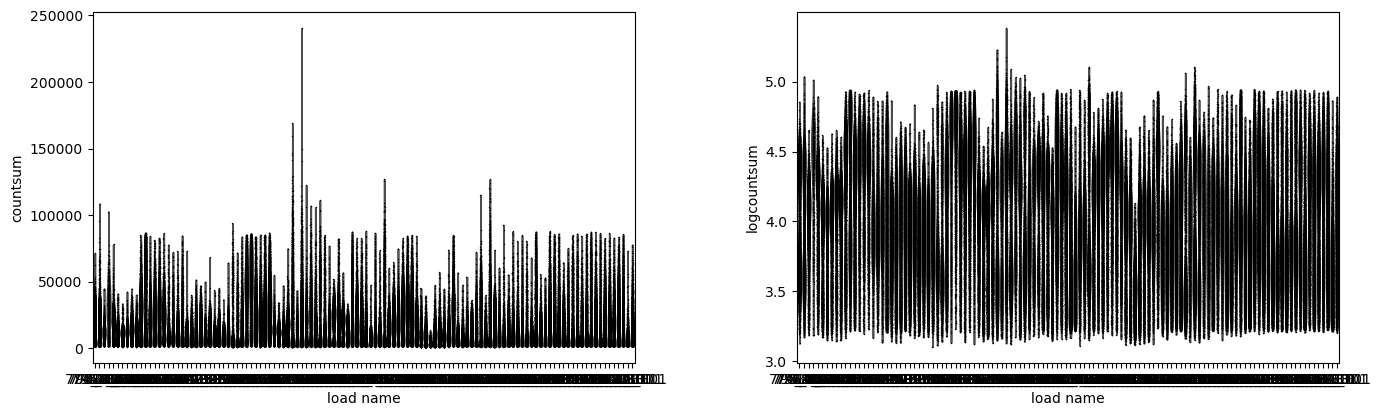

In [19]:
sc.pl.violin(adata,groupby='species',keys=['countsum','logcountsum'])
sc.pl.violin(adata,groupby='load_name',keys=['countsum','logcountsum'])


In [18]:
adata.var

,gene,n_counts,mean,std,mt,highly_variable-0-0,highly_variable_rank-0-0,means-0-0,variances-0-0,variances_norm-0-0,...,highly_variable_rank-1-0,means-1-0,variances-1-0,variances_norm-1-0,highly_variable-1,highly_variable_rank-1,means-1,variances-1,variances_norm-1,n_cells
ZNF692,ZNF692,80072.0,0.073422,0.235835,False,False,NaN,0.220105,0.286629,0.821865,...,NaN,0.150766,0.172183,0.871906,False,NaN,0.057739,0.064763,0.846101,76626
ZNF672,ZNF672,45105.0,0.044411,0.189770,False,False,NaN,0.108597,0.127277,0.816317,...,NaN,0.087651,0.096944,0.883274,False,NaN,0.038471,0.041355,0.839556,36256
SH3BP5L,SH3BP5L,64452.0,0.056326,0.201996,False,False,NaN,0.228490,0.300231,0.824702,...,NaN,0.109734,0.121574,0.870235,False,NaN,0.026589,0.028275,0.848490,45847
OR2T27,OR2T27,5.0,0.000005,0.001685,False,False,NaN,0.000000,0.000000,0.000000,...,NaN,0.000009,0.000009,0.992260,False,NaN,0.000000,0.000000,0.000000,850
OR2T10,OR2T10,10.0,0.000008,0.001914,False,False,NaN,0.000034,0.000034,0.989649,...,NaN,0.000023,0.000023,0.989609,False,NaN,0.000000,0.000000,0.000000,4814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TEKT4,TEKT4,395.0,0.000386,0.017663,False,False,NaN,0.002272,0.002424,1.000120,...,NaN,0.000163,0.000181,1.097619,False,NaN,0.000289,0.000342,1.154273,3669
CYP2E1,CYP2E1,702.0,0.000617,0.021109,False,False,NaN,0.003146,0.003248,0.948152,...,NaN,0.001017,0.001034,0.992433,False,NaN,0.000171,0.000171,0.982770,90447
PVR,PVR,99308.0,0.084696,0.244184,False,False,NaN,0.345964,0.490490,0.832167,...,NaN,0.175185,0.210734,0.905621,False,NaN,0.024000,0.026763,0.893714,91898
PLAC9,PLAC9,1620.0,0.002388,0.058172,False,False,NaN,0.002877,0.003428,1.101155,...,NaN,0.001460,0.001548,1.028541,False,NaN,0.002195,0.003084,1.239618,8101


In [13]:
adata=sc.read_h5ad(os.path.expanduser('/home/matthew.schmitz/Matthew/data/cortex_data/v1_combination.h5ad'))
adata.uns['species_colors']=['blue','red','green','yellow','orange','cyan','magenta','teal','goldenrod','purple','maroon','pink','violet','black','grey','beige']
batch_key='batch'
discov_key='species'
layer_key='UMIs'

In [ ]:
adata

In [15]:
adata.obs['countsum']=adata.layers['UMIs'].sum(-1)

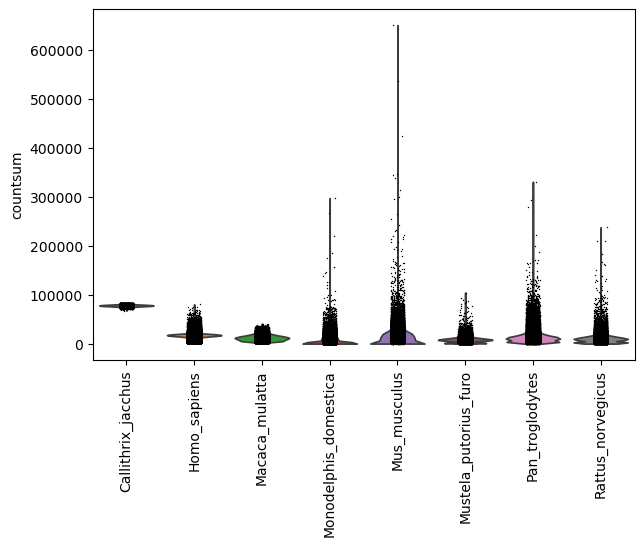

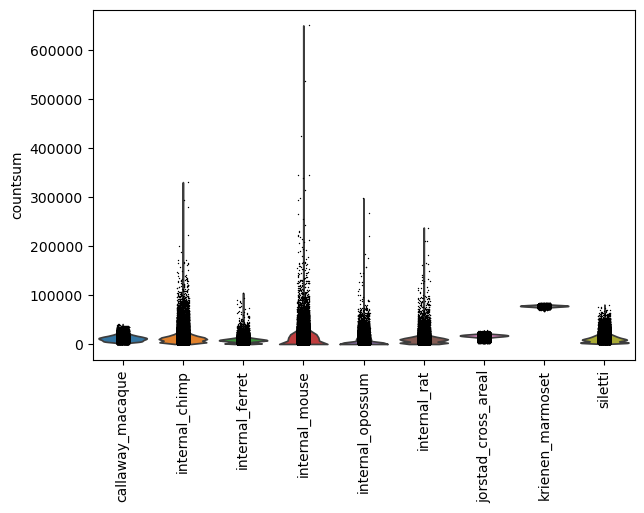

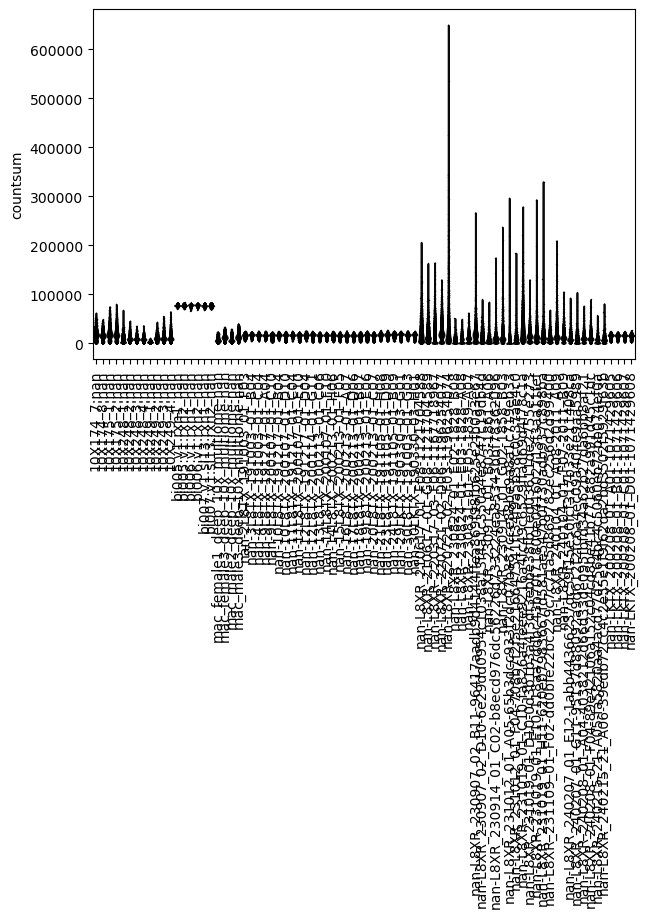

In [16]:
sc.pl.violin(adata,groupby='species',keys=['countsum'],rotation=90)
sc.pl.violin(adata,groupby='dataset',keys=['countsum'],rotation=90)
sc.pl.violin(adata,groupby='batch',keys=['countsum'],rotation=90)


In [17]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)


100%|██████████| 9/9 [01:27<00:00,  9.70s/it]


<Axes: ylabel='Proportion'>

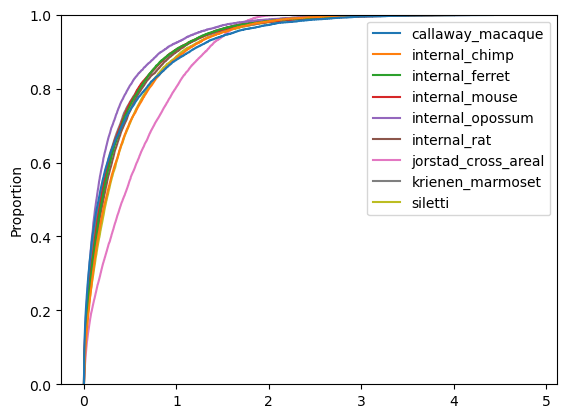

In [18]:
outs=antipode.model_functions.group_aggr_anndata(adata,['dataset'])
seaborn.ecdfplot(pd.DataFrame(outs[0],index=outs[1]['dataset']).T)